In [18]:
# Load Text

from general import load_text, load_json

report_path = '../../outputs/reports/2025/6.json'

reference = load_text('../../data/golden_standard/2025/6,7,8.txt')
reports = load_json(report_path)

Solo Safari menjadi destinasi yang  menarik di Surakarta dikarenakan tempatnya luas, bersih, dan cocok untuk tempat edukasi dan liburan bareng keluarga. Ramai pengunjung ceria dengan suasana nyaman, spot foto yang estetik, dan pertunjukan satwa yang cukup variatif. Anak-anak turut betah karena ada feeding satwa, pertunjukan satwa, hingga penyewaan skuter dan buggy car yang dapat digunakan untuk berkeliling di safari yang luas. Meski begitu, koleksi hewan yang masih sedikit dan area yang panas tetap menjadi underline keluhan dari pengunjung. Selain itu, harga tiket juga masih jadi keluhan utama, terutama tiket premium dan biaya tambahan lainnya, bahkan toilet turut berbayar. Dari bulan ke bulan, terlihat ada pembenahan, misalnya informasi show, staf pelayanan, hingga guide semakin jelas memberikan informasinya. Sayangnya, beberapa catatan soal pelayanan staf frontliner yang tidak ramah masih sering muncul. Akhir-akhir ini rerumputan yang gersang, danau kotor, hingga penerangan yang mini

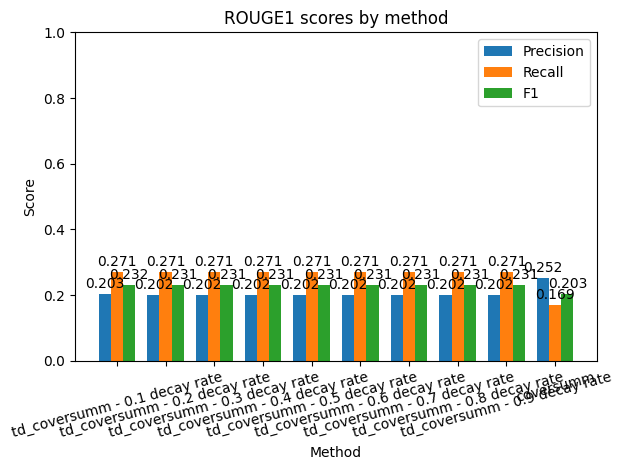

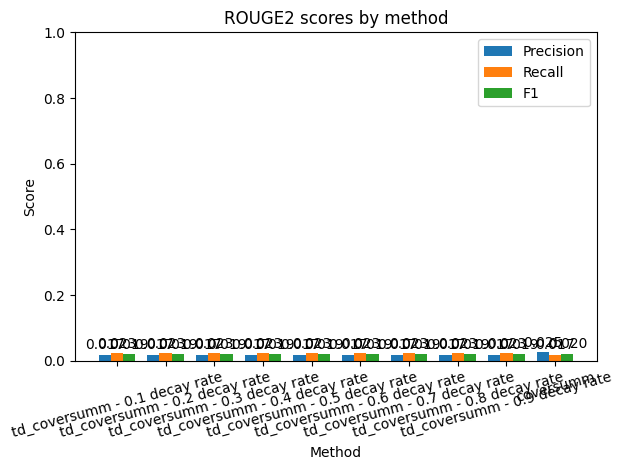

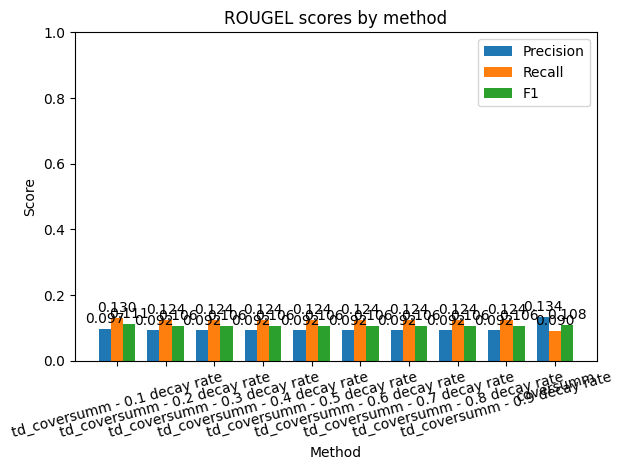

In [ ]:
from rouge_score import rouge_scorer
from matplotlib import pyplot as plt
import pandas as pd

def plot_metric(df, metric_name):
    x = range(len(df))
    width = 0.25

    fig, ax = plt.subplots(figsize=(10, 5))
    bars_p = ax.bar([i - width for i in x], df[f"{metric_name}_precision"], width, label="Precision")
    bars_r = ax.bar(x, df[f"{metric_name}_recall"], width, label="Recall")
    bars_f = ax.bar([i + width for i in x], df[f"{metric_name}_f1"], width, label="F1")

    ax.set_title(f"{metric_name.upper()} scores by method")
    ax.set_xticks(list(x))
    ax.set_xticklabels(df["method"], rotation=15)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Method")
    ax.set_ylabel("Score")
    ax.legend()

    for bars in [bars_p, bars_r, bars_f]:
        ax.bar_label(bars, fmt="%.3f", padding=2)

    plt.tight_layout()
    plt.show()

def getRougeScore(reference, candidate, metrics=("rouge1", "rouge2","rougeL")):
    print(candidate)

    scorer = rouge_scorer.RougeScorer(list(metrics), use_stemmer=True)
    scores = scorer.score(reference, candidate)

    out = {}
    for m in metrics:
        out[f"{m}_precision"] = scores[m].precision
        out[f"{m}_recall"]    = scores[m].recall
        out[f"{m}_f1"]        = scores[m].fmeasure
    return out

rows = []

print(reference)
for report in reports.values():
    method = report["summarizer"]
    candidate = report["summary_text"]
    candidate_score = getRougeScore(reference, candidate)
    rows.append({"method": method, **candidate_score})

df = pd.DataFrame(rows).sort_values("rouge1_recall", ascending=False).reset_index(drop=True)

for metric in ["rouge1", "rouge2", "rougeL"]:
    plot_metric(df, metric)